In [17]:
# import packages 

import torch
import matplotlib.pyplot as plt
from torch import nn
import warnings
warnings.filterwarnings("ignore")

from VeBNN.problems import PlasticityLaw
from VeBNN.networks import MeanNet, GammaVarNet
from VeBNN.methods.sgmcmc_trainer import SGMCMCTrainer
from matplotlib.ticker import ScalarFormatter
import numpy as np

## Load the  plasticity law discovery datset
The plasticity law discovery datset can be loaded by the class `PlasticityLaw`.

In [18]:
# load the dataset for training and testing purposes
plasticity_dataset = PlasticityLaw(dataset_path="plasticity_discovery/material_2_training_dataset.pickle",
                                  ground_truth=True,
                                  ground_truth_data_path="plasticity_discovery/material_2_testing_dataset.pickle")

# get the train, validate and test data
plasticity_dataset.get_train_val_split(num_train=100, num_val=100,)
# get the training, validate and test data
x_train_scaled, x_validate_scaled = plasticity_dataset.strain_train, plasticity_dataset.strain_validate
y_train_scaled, y_validate_scaled= plasticity_dataset.stress_train, plasticity_dataset.stress_validate
# get the ground truth data
plasticity_dataset.get_ground_truth()
# evaluate the model performance on ground truth data
strain_gt_scaled = plasticity_dataset.strain_ground_truth_normalized
stress_gt_mean_scaled = plasticity_dataset.stress_ground_truth_mean_normalized
stress_gt_std_scaled = plasticity_dataset.stress_ground_truth_std_normalized




## Define a GRU model from using default torch implementation

In [19]:
class SimpleGRU(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 output_size: int,
                 bias: bool = True):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          bias=bias,
                          batch_first=True,
                        )  
        self.h2y = nn.Linear(hidden_size, output_size)

    def forward(self, x, hx=None):
        out, _ = self.gru(x, hx)      # (B, T, hidden_size)
        y = self.h2y(out)             # (B, T, output_size)
        return y



In [20]:
# define the mean and variance networks
mean_network_ = SimpleGRU(input_size=3,
                         hidden_size=64,
                         num_layers=2,
                         output_size=3)
mean_network = MeanNet(net=mean_network_, 
                       prior_mu=0.0, 
                       prior_sigma=1.0)
# define the variance network
var_network_ = SimpleGRU(input_size=3,
                        hidden_size=64,
                        num_layers=2,
                        output_size=6)
var_network = GammaVarNet(net=var_network_,
                            prior_mu=0.0,
                            prior_sigma=1.0)

In [21]:
# set up the configuration for the VeBNN trainer
trainer = SGMCMCTrainer(mean_net=mean_network,
                          var_net=var_network,
                          device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                          job_id=1)
# ====== configs (kept small so test is fast) ======
init_config = {
    "loss_name": "MSE",
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "num_epochs": 100,      # warm-up epochs
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "split_ratio": 0.8,
}

var_config = {
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "num_epochs": 100,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "early_stopping": False,
    "early_stopping_iter": 100,
    "early_stopping_tol": 1e-4,
}

sampler_config = {
    "sampler": "pSGLD",   # must match your VeBNN.samplers names
    "lr": 1e-3,
    "gamma": 0.9999,
    "num_epochs": 200,    # SGMCMC epochs
    "mix_epochs": 10,     # thinning interval
    "burn_in_epochs": 100,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 100,
}

# ====== run cooperative training ======
# For a quick test, iteration=2 is enough to see if everything works.
trainer.cooperative_train(
    x_train=x_train_scaled,
    y_train=y_train_scaled,
    iteration=1,
    init_config=init_config,
    var_config=var_config,
    sampler_config=sampler_config,
    delete_model_raw_data=True,  # delete temporary folder after training
)



Epoch 1/100, Train loss: 1.040e+00, Val loss: 9.176e-01
Epoch 50/100, Train loss: 1.306e-01, Val loss: 1.417e-01
Epoch 100/100, Train loss: 6.229e-02, Val loss: 7.351e-02
Step 2: Train for the variance network, iteration 1
Epoch/Total: 0/100, Gamma NLL: 1.496e+04, neg log prior: 3.557e+04, log marginal likelihood: 0.000e+00
Epoch/Total: 50/100, Gamma NLL: -1.027e+04, neg log prior: 3.557e+04, log marginal likelihood: 0.000e+00
Finished training the variance network
Step 3: Train for the mean network with SGMCMC
Epoch 100/200, NLL: -1.143e+05, Neg log prior: 7.240e+04
Epoch 200/200, NLL: -1.163e+05, Neg log prior: 7.344e+04
Finished training the Bayesian mean network
Create model data folder to save the temporary models
Finished training the model
Delete the model data folder to free space


In [22]:
torch.save(trainer, f"VeBNN.pth")

In [23]:

# get the prediction from the bnn
pred, var_epistemic = trainer.bayes_predict(x=strain_gt_scaled)
# for aleatoric uncertainty
var_aleatoric= trainer.aleatoric_variance_predict(
    x=strain_gt_scaled)
# convert to cpu 
pred = pred.cpu().detach()
var_epistemic = var_epistemic.cpu().detach()
var_aleatoric = var_aleatoric.cpu().detach()
# set the 
# scale the prediction back
pred = pred * plasticity_dataset.stress_std + plasticity_dataset.stress_mean
var_epistemic = var_epistemic * plasticity_dataset.stress_std ** 2
var_aleatoric = var_aleatoric * plasticity_dataset.stress_std ** 2

In [24]:
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))

def brnn_prediction_plot(
    x_test: torch.Tensor,
    y_test: torch.Tensor,
    y_pred_mean: torch.Tensor,
    y_pred_var: torch.Tensor,
    y_pred_aleatoric: torch.Tensor,
    index: int,
    fig_name="rnn_prediction",
    save_fig: bool = False,
    y_test_var: torch.Tensor = None,
) -> None:

    strain = x_test.cpu().detach().numpy()
    stress = y_test.cpu().detach().numpy()
    y_pred_mean = y_pred_mean.cpu().detach().numpy()
    if y_pred_var is not None:
        y_pred_var = y_pred_var.cpu().detach().numpy()
    if y_test_var is not None:
        y_test_var = y_test_var.cpu().detach().numpy()
    if y_pred_aleatoric is not None:
        y_pred_aleatoric = y_pred_aleatoric.cpu().detach().numpy()

    fig, ax = plt.subplots(2, 3, figsize=(12, 5))

    ax[0, 0].plot(strain[index, :, 0], "-", color="#0077BB", linewidth=2)
    ax[0, 0].set_ylabel(ylabel=r"$E_{11}$", fontsize=12)
    ax[0, 0].yaxis.set_major_formatter(formatter)
    ax[0, 1].plot(strain[index, :, 1], "-", color="#0077BB", linewidth=2)
    ax[0, 1].set_ylabel(ylabel=r"$E_{12}$", fontsize=12)
    ax[0, 1].yaxis.set_major_formatter(formatter)
    ax[0, 2].plot(strain[index, :, 2], "-", color="#0077BB", linewidth=2)
    ax[0, 2].set_ylabel(ylabel=r"$E_{22}$", fontsize=12)
    ax[0, 2].yaxis.set_major_formatter(formatter)

    # plot the stress
    ax[1, 0].plot(stress[index, :, 0], "-", linewidth=2, color="#0077BB")
    if y_test_var is not None:
        ax[1, 0].fill_between(
            range(len(stress[index, :, 0])),
            y1=y_test[index, :, 0] - 2 * np.sqrt(y_test_var[index, :, 0]),
            y2=y_test[index, :, 0] + 2 * np.sqrt(y_test_var[index, :, 0]),
            edgecolor="none",
            color="#0077BB",
            alpha=0.3,
        )
    ax[1, 0].plot(y_pred_mean[index, :, 0], "-", color="#CC3311", linewidth=2)
    if y_pred_var is not None:
        ax[1, 0].fill_between(
            range(len(stress[index, :, 0])),
            y1=y_pred_mean[index, :, 0] - 2 * np.sqrt(y_pred_var[index, :, 0]),
            y2=y_pred_mean[index, :, 0] + 2 * np.sqrt(y_pred_var[index, :, 0]),
            edgecolor="none",
            color="#EE7733",
            alpha=0.5,
        )
    # plot the aleatoric uncertainty
    if y_pred_aleatoric is not None:
        ax[1, 0].fill_between(
            range(len(stress[index, :, 0])),
            y1=y_pred_mean[index, :, 0] - 2 *
            np.sqrt(y_pred_aleatoric[index, :, 0]),
            y2=y_pred_mean[index, :, 0] + 2 *
            np.sqrt(y_pred_aleatoric[index, :, 0]),
            alpha=0.6,
            color="gray",
            edgecolor="none",
        )

    ax[1, 0].set_xlabel(xlabel="Time step", fontsize=12)
    ax[1, 0].set_ylabel(ylabel=r"$\sigma_{11}$ (MPa)", fontsize=12)
    ax[1, 0].yaxis.set_major_formatter(formatter)
    ax[1, 1].plot(
        stress[index, :, 1],
        "-",
        linewidth=2,
        color="#0077BB",
    )
    if y_test_var is not None:
        ax[1, 1].fill_between(
            range(len(stress[index, :, 1])),
            y1=y_test[index, :, 1] - 2 * np.sqrt(y_test_var[index, :, 1]),
            y2=y_test[index, :, 1] + 2 * np.sqrt(y_test_var[index, :, 1]),
            edgecolor="none",
            color="#0077BB",
            alpha=0.3,
        )
    ax[1, 1].plot(
        y_pred_mean[index, :, 1],
        "-",
        color="#CC3311",
        linewidth=2,
    )
    if y_pred_var is not None:
        ax[1, 1].fill_between(
            range(len(stress[index, :, 1])),
            y1=y_pred_mean[index, :, 1] - 2 * np.sqrt(y_pred_var[index, :, 1]),
            y2=y_pred_mean[index, :, 1] + 2 * np.sqrt(y_pred_var[index, :, 1]),
            color="#EE7733",
            edgecolor="none",
            alpha=0.5,
        )
    # plot the aleatoric uncertainty
    if y_pred_aleatoric is not None:
        ax[1, 1].fill_between(
            range(len(stress[index, :, 1])),
            y1=y_pred_mean[index, :, 1] - 2 *
            np.sqrt(y_pred_aleatoric[index, :, 1]),
            y2=y_pred_mean[index, :, 1] + 2 *
            np.sqrt(y_pred_aleatoric[index, :, 1]),
            alpha=0.3,
            color="gray",
            edgecolor="none",
        )
    ax[1, 1].set_ylabel(ylabel=r"$\sigma_{12}$ (MPa)", fontsize=12)
    ax[1, 1].set_xlabel(xlabel="Time step", fontsize=12)

    ax[1, 1].yaxis.set_major_formatter(formatter)

    if y_test_var is not None:
        ax[1, 2].plot(
            stress[index, :, 2], "-", linewidth=2, color="#0077BB", label="Ground Truth Mean"
        )
        ax[1, 2].fill_between(
            range(len(stress[index, :, 2])),
            y1=y_test[index, :, 2] - 2 * np.sqrt(y_test_var[index, :, 2]),
            y2=y_test[index, :, 2] + 2 * np.sqrt(y_test_var[index, :, 2]),
            edgecolor="none",
            color="#0077BB",
            alpha=0.5,
            label="Ground Truth 95% CI",
        )
    else:
        ax[1, 2].plot(
            stress[index, :, 2], "-", linewidth=2, color="#0077BB", label="Test Data"
        )

    ax[1, 2].plot(
        y_pred_mean[index, :, 2], "-", color="#CC3311", linewidth=2, label="Pred. Mean"
    )
    if y_pred_var is not None:
        ax[1, 2].fill_between(
            range(len(stress[index, :, 2])),
            y1=y_pred_mean[index, :, 2] - 2 * np.sqrt(y_pred_var[index, :, 2]),
            y2=y_pred_mean[index, :, 2] + 2 * np.sqrt(y_pred_var[index, :, 2]),
            alpha=0.3,
            color="#EE7733",
            edgecolor="none",
            label="Pred. 95% CI Total",
        )
    # plot the aleatoric uncertainty
    if y_pred_aleatoric is not None:
        ax[1, 2].fill_between(
            range(len(stress[index, :, 2])),
            y1=y_pred_mean[index, :, 2] - 2 *
            np.sqrt(y_pred_aleatoric[index, :, 2]),
            y2=y_pred_mean[index, :, 2] + 2 *
            np.sqrt(y_pred_aleatoric[index, :, 2]),
            alpha=0.3,
            color="gray",
            edgecolor="none",
            label="Pred. 95% CI Aleatoric",
        )

    ax[1, 2].set_xlabel(xlabel="Time step", fontsize=12)
    ax[1, 2].set_ylabel(ylabel=r"$\sigma_{22}$ (MPa)", fontsize=12)
    ax[1, 2].legend(fontsize=8, loc="best", frameon=False)
    ax[1, 2].yaxis.set_major_formatter(formatter)

    # set the line width  and font size for the axises
    for i in range(2):
        for j in range(3):
            ax[i, j].tick_params(axis="both", which="major", labelsize=12)
            # set linewidth
            for axis in ["top", "bottom", "left", "right"]:
                ax[i, j].spines[axis].set_linewidth(1.5)
    # set the spaces for subplots
    plt.subplots_adjust(wspace=0.32, hspace=0.25)

    if save_fig:
        # plt.savefig(f"{fig_name}.pdf", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fig_name}.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()


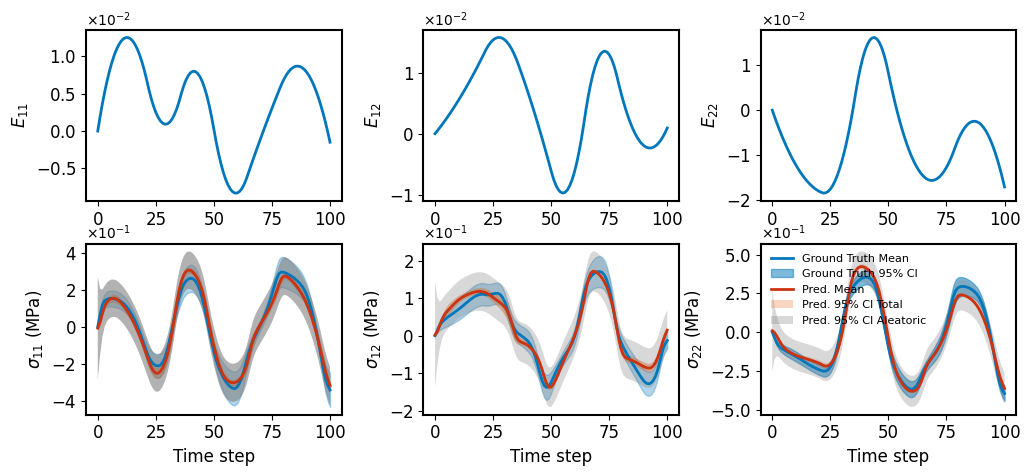

In [25]:
brnn_prediction_plot(
        x_test=plasticity_dataset.strain_ground_truth,
        y_test=plasticity_dataset.stress_ground_truth_mean,
        y_pred_mean=pred,
        y_pred_var=var_epistemic,
        y_pred_aleatoric=var_aleatoric,
        index=1,
        save_fig=False,
        y_test_var=plasticity_dataset.stress_ground_truth_std**2,
    )